# Hotel Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("delhi_hotel_bookings_july_2026_synthetic.csv", encoding = "unicode_escape")

In [3]:
data.head(5)

,Booking_ID,Hotel_Area,Hotel_Tier,Room_Type,Check_In,Check_Out,Nights,Rooms,ADR_INR,Booking_Status,Booking_Channel,Customer_Type,Estimated_Occupancy,Booking_Revenue_INR
0,DELJUL26-00001,Aerocity,Midscale,Standard,2026-07-27,2026-08-01,5,2,7713,Cancelled,Agoda,Couple,0.525,0
1,DELJUL26-00002,Greater Kailash,Midscale,Standard,2026-07-15,2026-07-19,4,2,6482,Confirmed,Direct,Business,0.423,51853
2,DELJUL26-00003,South Delhi,Budget,Suite,2026-07-22,2026-07-24,2,2,4684,Confirmed,Booking.com,Group,0.414,18734
3,DELJUL26-00004,Saket,Economy,Standard,2026-07-30,2026-08-04,5,1,6398,Completed,Direct,Couple,0.356,31991
4,DELJUL26-00005,Saket,Midscale,Standard,2026-07-02,2026-07-07,5,2,4999,Confirmed,MakeMyTrip,Couple,0.937,49987


In [4]:
data.shape

(5000, 14)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Booking_ID           5000 non-null   str    
 1   Hotel_Area           5000 non-null   str    
 2   Hotel_Tier           5000 non-null   str    
 3   Room_Type            5000 non-null   str    
 4   Check_In             5000 non-null   str    
 5   Check_Out            5000 non-null   str    
 6   Nights               5000 non-null   int64  
 7   Rooms                5000 non-null   int64  
 8   ADR_INR              5000 non-null   int64  
 9   Booking_Status       5000 non-null   str    
 10  Booking_Channel      5000 non-null   str    
 11  Customer_Type        5000 non-null   str    
 12  Estimated_Occupancy  5000 non-null   float64
 13  Booking_Revenue_INR  5000 non-null   int64  
dtypes: float64(1), int64(4), str(9)
memory usage: 547.0 KB


In [6]:
data.describe()

,Nights,Rooms,ADR_INR,Estimated_Occupancy,Booking_Revenue_INR
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,3.042200,2.001800,5184.019200,0.650177,29078.64880
std,1.433189,0.812606,3574.634166,0.173917,32717.81075
min,1.000000,1.000000,799.000000,0.350000,0.00000
25%,2.000000,1.000000,2673.750000,0.501000,7998.75000
50%,3.000000,2.000000,4206.000000,0.652000,18892.50000
75%,4.000000,3.000000,6581.000000,0.801000,38323.25000
max,5.000000,3.000000,27991.000000,0.950000,337800.00000


In [7]:
data.columns

Index(['Booking_ID', 'Hotel_Area', 'Hotel_Tier', 'Room_Type', 'Check_In',
       'Check_Out', 'Nights', 'Rooms', 'ADR_INR', 'Booking_Status',
       'Booking_Channel', 'Customer_Type', 'Estimated_Occupancy',
       'Booking_Revenue_INR'],
      dtype='str')

In [8]:
pd.isnull(data).sum()

Booking_ID             0
Hotel_Area             0
Hotel_Tier             0
Room_Type              0
Check_In               0
Check_Out              0
Nights                 0
Rooms                  0
ADR_INR                0
Booking_Status         0
Booking_Channel        0
Customer_Type          0
Estimated_Occupancy    0
Booking_Revenue_INR    0
dtype: int64

In [9]:
data.groupby(['Customer_Type','Booking_Status', 'Room_Type' ], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by = "Booking_Revenue_INR", ascending = False)

,Customer_Type,Booking_Status,Room_Type,Booking_Revenue_INR
22,Couple,Confirmed,Standard,9496573
46,Group,Confirmed,Standard,8007124
10,Business,Confirmed,Standard,7720275
42,Group,Completed,Standard,7513730
18,Couple,Completed,Standard,7434305
34,Family,Confirmed,Standard,7407443
58,Leisure,Confirmed,Standard,7079033
30,Family,Completed,Standard,7004225
54,Leisure,Completed,Standard,5781705
6,Business,Completed,Standard,5750328


In [10]:
data.groupby(['Customer_Type'], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by ='Booking_Revenue_INR', ascending = False )


,Customer_Type,Booking_Revenue_INR
1,Couple,31752923
3,Group,31069513
4,Leisure,27718438
2,Family,27592975
0,Business,27259395


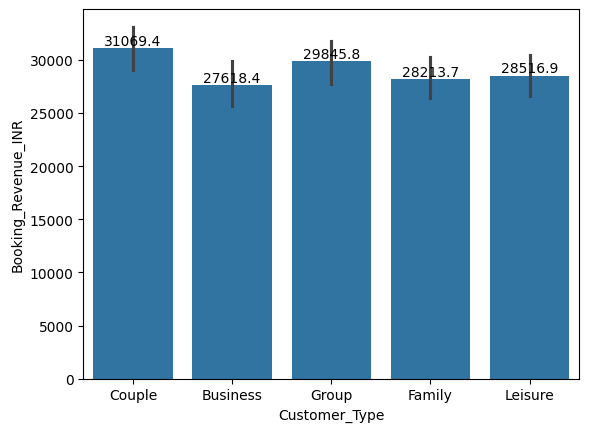

In [11]:
ax=sns.barplot(x= 'Customer_Type', y = 'Booking_Revenue_INR', data = data)
for bars in ax.containers:
    ax.bar_label(bars)

From the above data, we have find out that in customer tyoe column "couple" has mostly spent money for booking a hotel in a month  


In [12]:
data.groupby(['Booking_Status'], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by ='Booking_Revenue_INR', ascending = False )

,Booking_Status,Booking_Revenue_INR
2,Confirmed,77239462
1,Completed,68153782
0,Cancelled,0


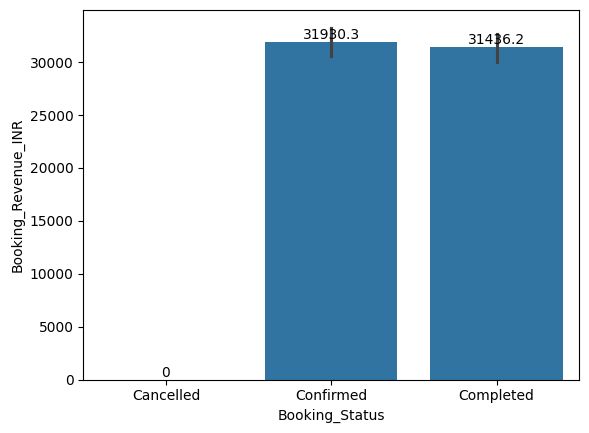

In [13]:
ax = sns.barplot(x='Booking_Status',y= 'Booking_Revenue_INR', data=data)
for bars in ax.containers:
    ax.bar_label(bars)

From the above data, we hace conclude that 'Booking status' are mostly Confiemed and Completed.

In [14]:
data.groupby(['Room_Type'], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by ='Booking_Revenue_INR', ascending = False )

,Room_Type,Booking_Revenue_INR
2,Standard,73194741
0,Deluxe,42063627
1,Premium,22827767
3,Suite,7307109


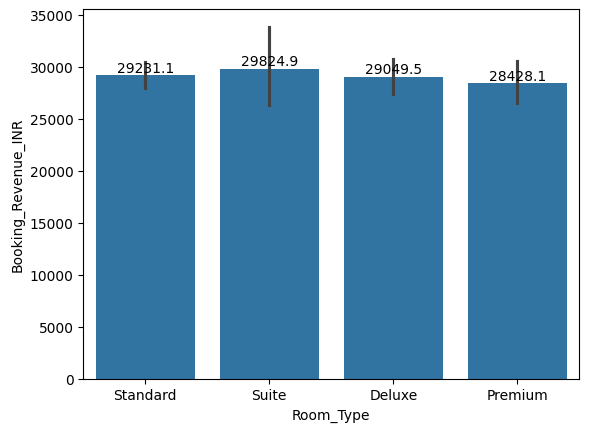

In [15]:
ax = sns.barplot(x='Room_Type',y= 'Booking_Revenue_INR', data=data)
for bars in ax.containers:
    ax.bar_label(bars)

From the above data we have conclude that the 'Room type' are mostly equal uses in a month dataset.

In [16]:
data['Hotel_Area'].unique()

<StringArray>
[       'Aerocity', 'Greater Kailash',     'South Delhi',           'Saket',
    'Lajpat Nagar',      'Karol Bagh',          'Dwarka',          'Rohini',
 'Connaught Place',       'Paharganj']
Length: 10, dtype: str

In [17]:
district_mapping = {
    'Aerocity': 'South West Delhi',
    'Connaught Place': 'New Delhi',
    'Dwarka': 'South West Delhi',
    'Greater Kailash': 'South East Delhi',
    'Karol Bagh': 'Central Delhi',
    'Lajpat Nagar': 'South East Delhi',
    'Paharganj': 'Central Delhi',
    'Rohini': 'North West Delhi',
    'Saket': 'South Delhi',
    'South Delhi': 'South Delhi'
}

In [18]:
data['District'] = data['Hotel_Area'].map(district_mapping)

In [19]:
data[['Hotel_Area', 'District']].drop_duplicates().sort_values('District')


,Hotel_Area,District
8,Karol Bagh,Central Delhi
21,Paharganj,Central Delhi
17,Connaught Place,New Delhi
11,Rohini,North West Delhi
2,South Delhi,South Delhi
3,Saket,South Delhi
1,Greater Kailash,South East Delhi
5,Lajpat Nagar,South East Delhi
0,Aerocity,South West Delhi
10,Dwarka,South West Delhi


In [20]:
data['District'].value_counts()

District
South East Delhi    1002
South West Delhi     989
Central Delhi        974
South Delhi          972
New Delhi            543
North West Delhi     520
Name: count, dtype: int64

<Axes: xlabel='District', ylabel='Booking_Revenue_INR'>

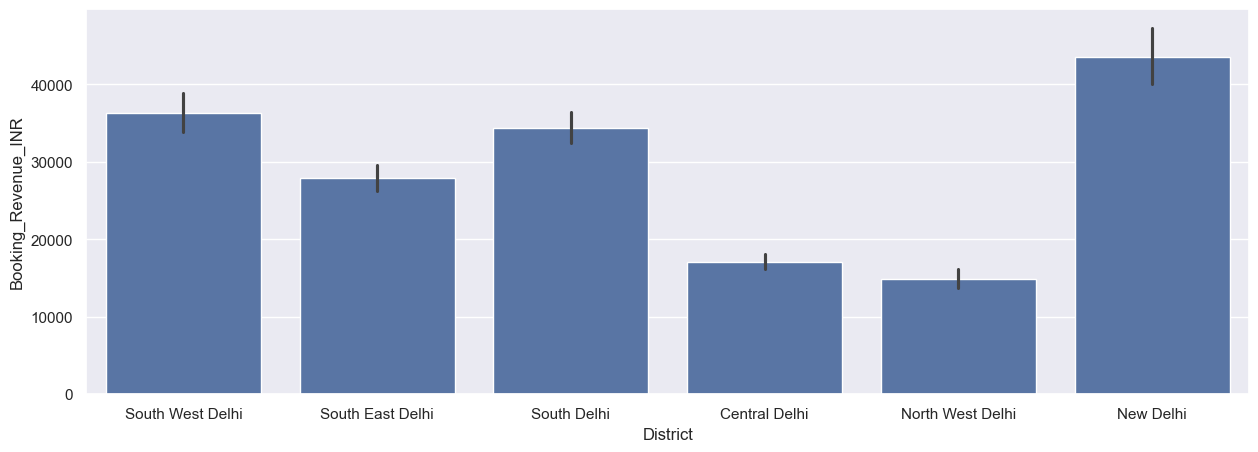

In [21]:
sns.set(rc = {"figure.figsize" : (15,5)})
sns.barplot(x='District', y='Booking_Revenue_INR',data = data)

From the above data, we can find out the "New Delhi" district has mostly booking area and get a profitable Revenue in a month.

In [22]:
district_adr = (
    data.groupby('District')['ADR_INR']
    .mean()
    .sort_values(ascending=False)
)

district_adr

District
New Delhi           7606.362799
South West Delhi    6548.233569
South Delhi         6008.344650
South East Delhi    5153.237525
Central Delhi       2946.370637
North West Delhi    2769.650000
Name: ADR_INR, dtype: float64

According to the average mean value of District, we had get the mostly "New Delhi" district got a profitable revenue in a whole month.

In [23]:
district_revenue = (
    data.groupby('District')['ADR_INR']
    .sum()
    .sort_values(ascending=False)
)

district_revenue

District
South West Delhi    6476203
South Delhi         5840111
South East Delhi    5163544
New Delhi           4130255
Central Delhi       2869765
North West Delhi    1440218
Name: ADR_INR, dtype: int64

In [24]:
data.columns

Index(['Booking_ID', 'Hotel_Area', 'Hotel_Tier', 'Room_Type', 'Check_In',
       'Check_Out', 'Nights', 'Rooms', 'ADR_INR', 'Booking_Status',
       'Booking_Channel', 'Customer_Type', 'Estimated_Occupancy',
       'Booking_Revenue_INR', 'District'],
      dtype='str')

In [25]:
data.head(5)

,Booking_ID,Hotel_Area,Hotel_Tier,Room_Type,Check_In,Check_Out,Nights,Rooms,ADR_INR,Booking_Status,Booking_Channel,Customer_Type,Estimated_Occupancy,Booking_Revenue_INR,District
0,DELJUL26-00001,Aerocity,Midscale,Standard,2026-07-27,2026-08-01,5,2,7713,Cancelled,Agoda,Couple,0.525,0,South West Delhi
1,DELJUL26-00002,Greater Kailash,Midscale,Standard,2026-07-15,2026-07-19,4,2,6482,Confirmed,Direct,Business,0.423,51853,South East Delhi
2,DELJUL26-00003,South Delhi,Budget,Suite,2026-07-22,2026-07-24,2,2,4684,Confirmed,Booking.com,Group,0.414,18734,South Delhi
3,DELJUL26-00004,Saket,Economy,Standard,2026-07-30,2026-08-04,5,1,6398,Completed,Direct,Couple,0.356,31991,South Delhi
4,DELJUL26-00005,Saket,Midscale,Standard,2026-07-02,2026-07-07,5,2,4999,Confirmed,MakeMyTrip,Couple,0.937,49987,South Delhi


In [26]:
data.groupby(['Booking_Channel','Estimated_Occupancy'], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by = 'Booking_Revenue_INR', ascending = False)

,Booking_Channel,Estimated_Occupancy,Booking_Revenue_INR
1996,MakeMyTrip,0.572,391754
1612,Goibibo,0.677,379486
1763,Goibibo,0.872,375000
2570,Walk-in,0.735,337800
131,Agoda,0.525,325860
...,...,...,...
2127,MakeMyTrip,0.750,0
756,Booking.com,0.751,0
836,Booking.com,0.857,0
40,Agoda,0.405,0


In [27]:
data.groupby(['Booking_Channel'], as_index = False)['Booking_Revenue_INR'].sum().sort_values(by = "Booking_Revenue_INR", ascending = False)

,Booking_Channel,Booking_Revenue_INR
3,Goibibo,25623567
5,Walk-in,24379895
2,Direct,24335672
1,Booking.com,23910713
4,MakeMyTrip,23605788
0,Agoda,23537609


<Axes: xlabel='Booking_Channel', ylabel='Booking_Revenue_INR'>

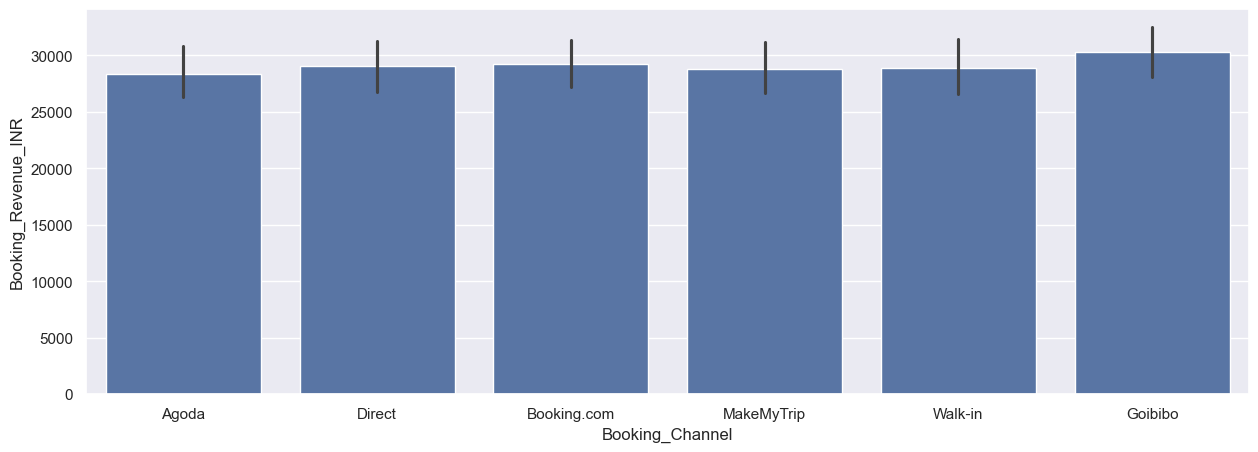

In [28]:
sns.barplot(x='Booking_Channel', y='Booking_Revenue_INR', data = data)

At the end, from the above dataset we have get the mostly equal booking by every booking channel and provide a profitable profit but "Gobibo" are mostlt used by the consumers for booking a hotel in a month.

In [29]:
data['Check_In'] = pd.to_datetime(data['Check_In'])
data['Check_Out'] = pd.to_datetime(data['Check_Out'])

In [30]:
july_data = data[
    (data['Check_In'].dt.month == 7) &
    (data['Check_In'].dt.year == 2026)
]

total_checkins = july_data['Check_In'].count()

total_checkins

np.int64(5000)

In [31]:
july_checkouts = data[
    (data['Check_Out'].dt.month == 7) &
    (data['Check_Out'].dt.year == 2026)
]

total_checkouts = july_checkouts['Check_Out'].count()

total_checkouts

np.int64(4545)

In [32]:
avg_daily_checkin = total_checkins / 31
avg_daily_checkout = total_checkouts / 31

print("Average Daily Check-In:", avg_daily_checkin)
print("Average Daily Check-Out:", avg_daily_checkout)

Average Daily Check-In: 161.29032258064515
Average Daily Check-Out: 146.61290322580646


So, the daily average value of  'check-in' in a hotel is 161 people
and the daily average value of  'check-out' in a hotel is 147 people in a whole city.

In [33]:
district_checkin = (
    july_data
    .groupby('District')['Check_In']
    .count()
    .reset_index(name='Total_Check_In')
)

district_checkin['Average_Daily_Check_In'] = (
    district_checkin['Total_Check_In'] / 31
)

district_checkin

,District,Total_Check_In,Average_Daily_Check_In
0,Central Delhi,974,31.419355
1,New Delhi,543,17.516129
2,North West Delhi,520,16.774194
3,South Delhi,972,31.354839
4,South East Delhi,1002,32.322581
5,South West Delhi,989,31.903226


In [34]:
july_checkouts = data[
    (data['Check_Out'].dt.month == 7) &
    (data['Check_Out'].dt.year == 2026)
]

district_checkout = (
    july_checkouts
    .groupby('District')['Check_Out']
    .count()
    .reset_index(name='Total_Check_Out')
)

district_checkout['Average_Daily_Check_Out'] = (
    district_checkout['Total_Check_Out'] / 31
)

district_checkout

,District,Total_Check_Out,Average_Daily_Check_Out
0,Central Delhi,893,28.806452
1,New Delhi,500,16.129032
2,North West Delhi,466,15.032258
3,South Delhi,886,28.580645
4,South East Delhi,912,29.419355
5,South West Delhi,888,28.645161


In [35]:
district_average = pd.merge(
    district_checkin,
    district_checkout,
    on='District',
    how='outer'
)

district_average

,District,Total_Check_In,Average_Daily_Check_In,Total_Check_Out,Average_Daily_Check_Out
0,Central Delhi,974,31.419355,893,28.806452
1,New Delhi,543,17.516129,500,16.129032
2,North West Delhi,520,16.774194,466,15.032258
3,South Delhi,972,31.354839,886,28.580645
4,South East Delhi,1002,32.322581,912,29.419355
5,South West Delhi,989,31.903226,888,28.645161


Now, we get the average "check-in" and "check-out" details by every district.

In [36]:
occupancy_data = data[
    data['Booking_Status'].isin(['Confirmed', 'Completed'])
].copy()

In [37]:
july_days = pd.date_range(
    start='2026-07-01',
    end='2026-07-31',
    freq='D'
)

In [38]:
daily_occupancy = []

for day in july_days:
    
    occupied_rooms = occupancy_data[
        (occupancy_data['Check_In'] <= day) &
        (occupancy_data['Check_Out'] > day)
    ]['Rooms'].sum()
    
    daily_occupancy.append({
        'Date': day,
        'Occupied_Rooms': occupied_rooms
    })

daily_occupancy = pd.DataFrame(daily_occupancy)

daily_occupancy.head(4)

,Date,Occupied_Rooms
0,2026-07-01,323
1,2026-07-02,552
2,2026-07-03,751
3,2026-07-04,837


In [39]:
district_daily_summary = pd.pivot_table(
    data,
    index='Check_In',
    columns='District',
    values='Booking_ID',
    aggfunc='count',
    fill_value=0
)

district_daily_summary.head(4)

District,Central Delhi,New Delhi,North West Delhi,South Delhi,South East Delhi,South West Delhi
Check_In,,,,,,
2026-07-01,34,14,17,29,50,36
2026-07-02,34,16,19,30,37,27
2026-07-03,35,21,14,35,30,29
2026-07-04,35,25,11,27,25,38


In [40]:
district_daily_summary = pd.pivot_table(
    data,
    index='Check_Out',
    columns='District',
    values='Booking_ID',
    aggfunc='count',
    fill_value=0
)

district_daily_summary.head(4)

District,Central Delhi,New Delhi,North West Delhi,South Delhi,South East Delhi,South West Delhi
Check_Out,,,,,,
2026-07-02,7,2,1,2,12,10
2026-07-03,9,4,6,15,15,9
2026-07-04,21,7,12,20,30,27
2026-07-05,29,17,13,25,37,24


# Summary:


We are find out the 'couple' are mostly spent money for booking a hotel and whole the bookings are confirmed and completed. Doesn't have cancelled any booking. Customers are mostly equal uses every Room type in every hotel and we are get mostly profitable revenue from the 'New Delhi' District hotels in a month and consumers are equally use every channel for booking a hotel but mostly uses 'Gobibo' for confirming his booking. The daily average check-in and check-out values in city hotel is 161 and 147 but when we separate it according to their district, we get some different values like 
'District'-New Delhi, 'Total Check-In' - 974, 'Total Check-Out' - 893, 'Average_Daily_Check_In' - 31.419355, 'Average_Daily_Check_Out'- 28.806452 .

And we get briefly information of check-in and check-out according to each date booking in every district for occupied rooms in a hotels.
